In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [6]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import *
import matplotlib.pyplot as plt

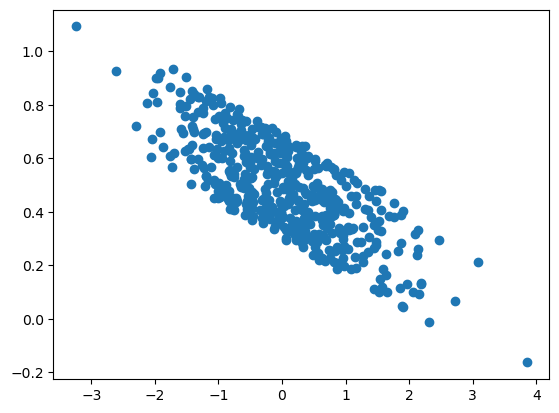

In [7]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [8]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 0.22389665936596004, Val loss:0.22227217013685469
100. Training loss: 0.04473791353662412, Val loss:0.04350687132083246
150. Training loss: 0.01808305147702868, Val loss:0.017079948707739195
200. Training loss: 0.014116985551358615, Val loss:0.013210362684918413
250. Training loss: 0.013526808616498796, Val loss:0.012658557107672769
300. Training loss: 0.013438979611857652, Val loss:0.012585780449882417
350. Training loss: 0.013425908200894935, Val loss:0.01257859777405428
400. Training loss: 0.013423962698572107, Val loss:0.012578954541903345
450. Training loss: 0.013423673122704472, Val loss:0.012579564566392844
500. Training loss: 0.013423630019323562, Val loss:0.012579872725242275


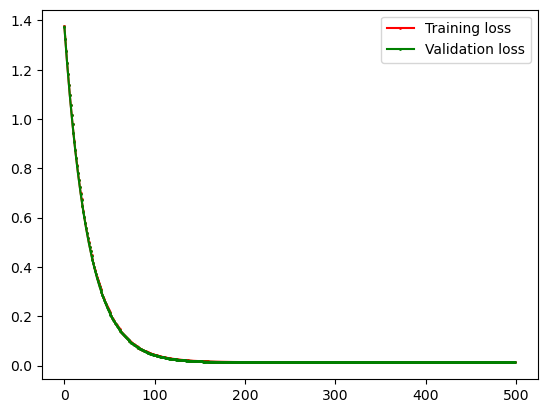

,dim,1
,is_reg,True
,loss_fn,<function MSE at 0x1693b2290>
,grad_fn,<function MSE...t 0x16a040ee0>
,act_fn,<function Lin...t 0x16a14f7f0>
,lr,0.1
,reg_type,''
,reg_lambda,0
,n_iteration,50
,val_ratio,0.2
,random_state,None


In [9]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [12]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [ ]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013355229539356039,
 'MAE': 0.10095149880498926,
 'RMSE': np.float64(0.11556482829717717),
 'R-squared': 0.5689997481843656}

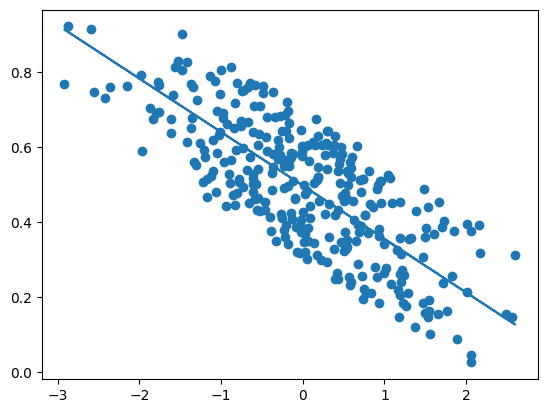

In [ ]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()